In [1]:
import pandas as pd
import os

def process_residuals(file_path, tolerance=0.05, max_points=31):
    df = pd.read_csv(file_path)

    config_ids = []
    current_config = 1
    point_in_config = 1
    last_y = df['y_true'].iloc[0]

    config_ids.append(f"config{current_config}")
    current_indices = [1]

    for i in range(1, len(df)):
        y = df['y_true'].iloc[i]
        delta = y - last_y

        # Check if new configuration starts:
        if delta > tolerance or point_in_config >= max_points:
            current_config += 1
            point_in_config = 1
        else:
            point_in_config += 1

        config_ids.append(f"config{current_config}")
        current_indices.append(point_in_config)
        last_y = y

    df['configuration'] = config_ids
    df['current_density_index'] = current_indices

    return df

In [2]:

# Example usage
fold = 1  # Change this from 1 to 5 as needed
file_path = f"../results/sm/xgboost/residuals/residuals_fold{fold}.csv"

df_processed = process_residuals(file_path)
df_processed

,y_true,y_pred,residual,configuration,current_density_index
0,0.864067,0.853209,0.010857,config1,1
1,0.819164,0.820445,-0.001281,config1,2
2,0.788480,0.788038,0.000442,config1,3
3,0.763919,0.726666,0.037252,config1,4
4,0.742850,0.698641,0.044209,config1,5
...,...,...,...,...,...
309242,0.462586,0.454643,0.007943,config10000,27
309243,0.451073,0.448079,0.002994,config10000,28
309244,0.439618,0.438410,0.001208,config10000,29
309245,0.428213,0.436206,-0.007993,config10000,30


In [3]:
df_processed.groupby("configuration").max("current_density_index")["current_density_index"].value_counts()

current_density_index
31    9870
27      15
20      14
28      13
26      13
29      13
30      12
22      12
24      11
25      11
21       9
23       7
Name: count, dtype: int64

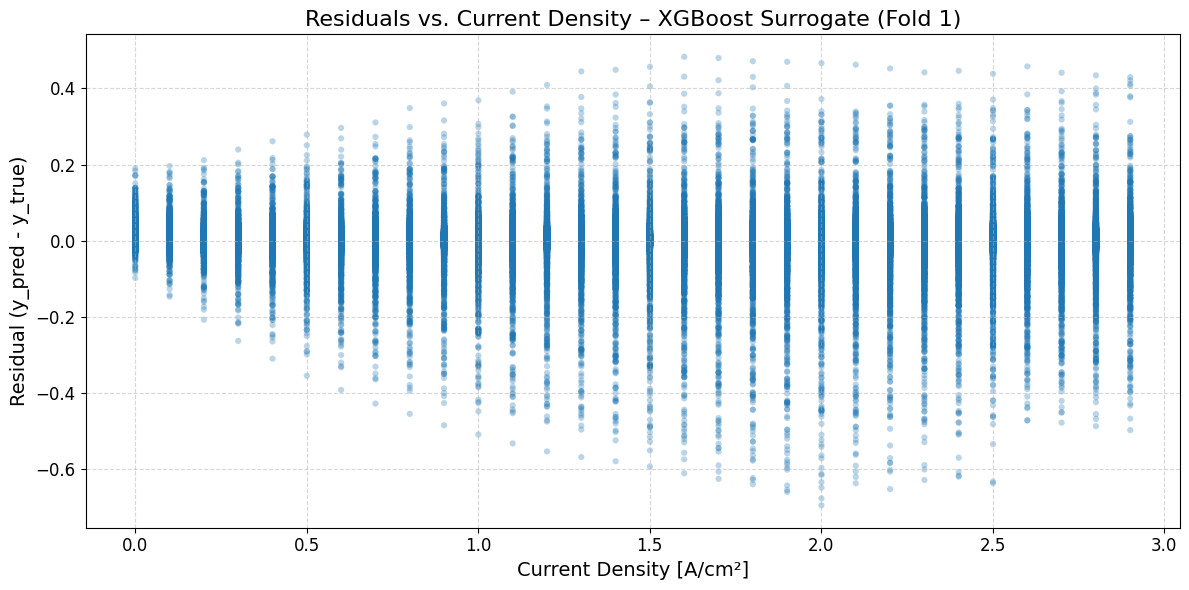

In [28]:
import matplotlib.pyplot as plt

def plot_residuals_vs_current_density(df, fold):
    # Mapping from index (1–30) to current density values
    current_density_map = {
        i + 1: val for i, val in enumerate([
            0.000820796, 0.10081943643864154, 0.20081943643848774, 0.3008194364384895,
            0.4008194364384925, 0.5008194364384955, 0.6008194364384984, 0.7008194364385013,
            0.8008194364385044, 0.9008194364385074, 1.0008194364385103, 1.100819436438513,
            1.2008194364385163, 1.3008194364385193, 1.400819436438522, 1.500819436438525,
            1.600819436438515, 1.7008194364385032, 1.800819436438491, 1.9008194364384792,
            2.0008194364384675, 2.1008194364384556, 2.2008194364384437, 2.300819436438432,
            2.400819436, 2.5008194364384084, 2.600819436438396, 2.7008194364383846,
            2.8008194364383727, 2.900819436438361
        ])
    }

    # Create a new column with actual current density values
    df = df.copy()
    df['current_density'] = df['current_density_index'].map(current_density_map)

    plt.figure(figsize=(12, 6))

    plt.scatter(
        df['current_density'],
        df['residual'],
        alpha=0.3,
        s=20,
        edgecolors='none'
    )

    plt.title(f"Residuals vs. Current Density – XGBoost Surrogate (Fold {fold})", fontsize=17)
    plt.xlabel("Current Density [A/cm²]", fontsize=14)
    plt.ylabel("Residual (y_pred - y_true)", fontsize=14)

    plt.xticks(fontsize=12)
    plt.yticks(fontsize=12)
    plt.grid(True, linestyle='--', alpha=0.5)

    plt.tight_layout()
    plt.show()

# Example usage
plot_residuals_vs_current_density(df_processed, fold=1)

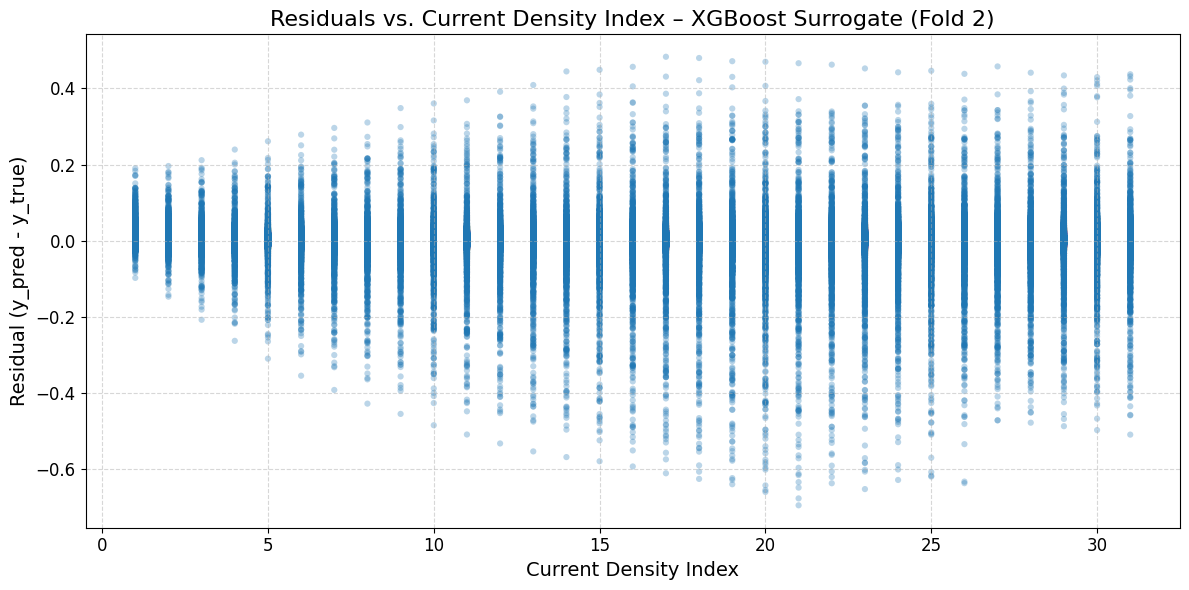

In [6]:
plot_residuals_vs_current_density(df_processed, fold=2)

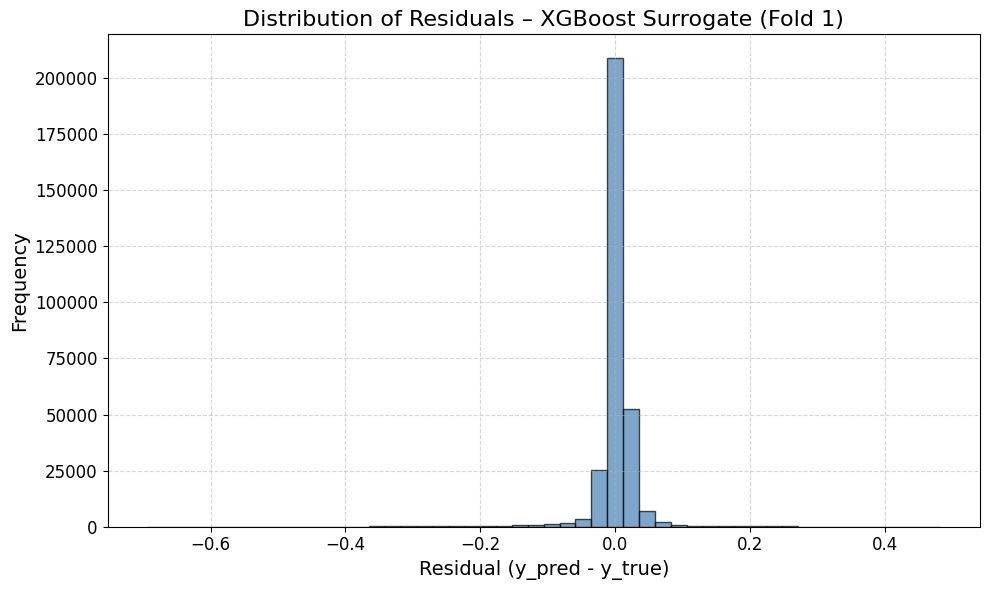

In [7]:
def plot_residuals_histogram(df, fold):
    plt.figure(figsize=(10, 6))
    
    plt.hist(df['residual'], bins=50, alpha=0.7, color='steelblue', edgecolor='black')
    
    plt.title(f"Distribution of Residuals – XGBoost Surrogate (Fold {fold})", fontsize=16)
    plt.xlabel("Residual (y_pred - y_true)", fontsize=14)
    plt.ylabel("Frequency", fontsize=14)
    
    plt.xticks(fontsize=12)
    plt.yticks(fontsize=12)
    plt.grid(True, linestyle='--', alpha=0.5)
    
    plt.tight_layout()
    plt.show()

# Example usage
plot_residuals_histogram(df_processed, fold=1)


In [26]:
import matplotlib.pyplot as plt
import seaborn as sns

def plot_residuals_boxplot(df, fold):
    # Mapping from index (1–30) to current density values
    current_density_map = {
        i +1: val for i, val in enumerate([
            0.000820796, 0.10081943643864154, 0.20081943643848774, 0.3008194364384895,
            0.4008194364384925, 0.5008194364384955, 0.6008194364384984, 0.7008194364385013,
            0.8008194364385044, 0.9008194364385074, 1.0008194364385103, 1.100819436438513,
            1.2008194364385163, 1.3008194364385193, 1.400819436438522, 1.500819436438525,
            1.600819436438515, 1.7008194364385032, 1.800819436438491, 1.9008194364384792,
            2.0008194364384675, 2.1008194364384556, 2.2008194364384437, 2.300819436438432,
            2.400819436, 2.5008194364384084, 2.600819436438396, 2.7008194364383846,
            2.8008194364383727, 2.900819436438361, 3.000819436438349
        ])
    }

    plt.figure(figsize=(14, 6))

    sns.boxplot(
        data=df,
        x='current_density_index',
        y='residual',
        color='skyblue',
        fliersize=2,
        linewidth=1
    )

    # Replace x-ticks with current density values
    tick_indices = sorted(df['current_density_index'].unique())
    tick_labels = []
    for i in tick_indices:
        if i in current_density_map:
            tick_labels.append(f"{current_density_map[i]:.2f}")
        else:
            tick_labels.append(str(i))  # fallback label

    plt.xticks(ticks=range(len(tick_indices)), labels=tick_labels, rotation=0, fontsize=9)

    plt.title(f"Residual Distribution by Current Density – XGBoost Surrogate (Fold {fold})", fontsize=17)
    plt.xlabel("Current Density [A/cm²]", fontsize=14)
    plt.ylabel("Residual (y_pred - y_true)", fontsize=14)

    plt.yticks(fontsize=12)
    plt.grid(True, linestyle='--', axis='y', alpha=0.5)

    plt.tight_layout()
    plt.show()


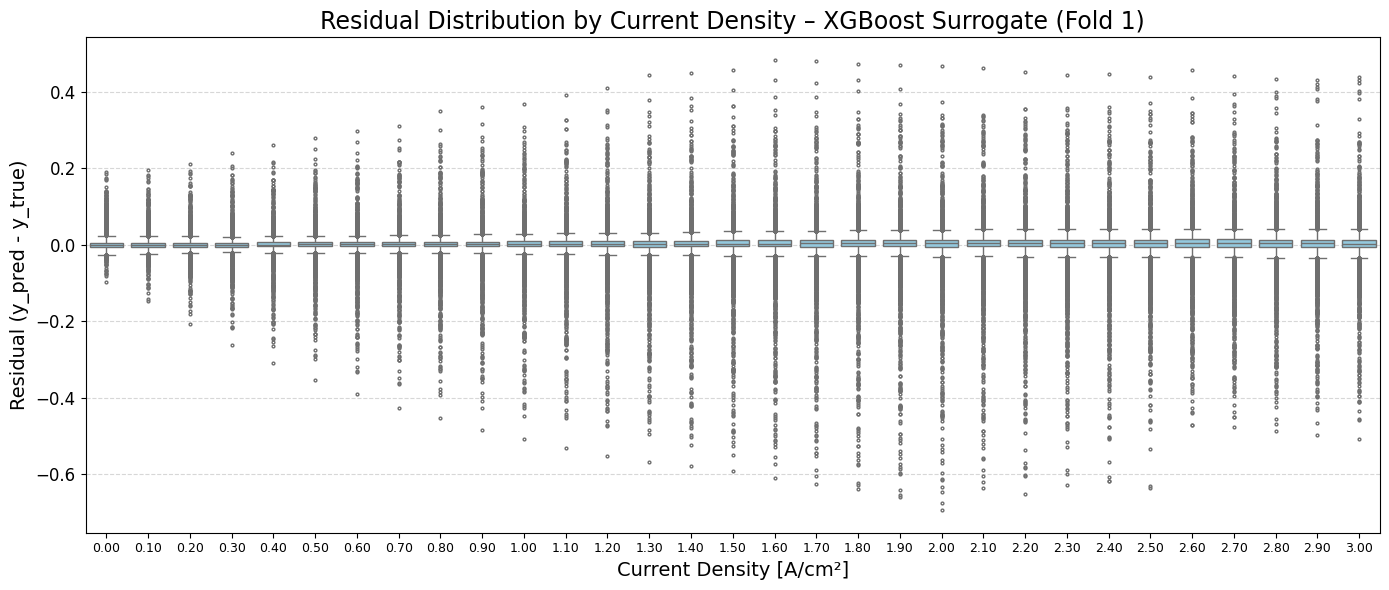

In [27]:
plot_residuals_boxplot(df_processed, fold=1)

In [5]:
df_processed["configuration"].nunique()

10000

In [ ]:

# Save or inspect
output_path = f"../results/sm/xgboost/residuals/residuals_fold{fold}_processed.csv"
df_processed.to_csv(output_path, index=False)

print(f"Processed fold {fold} saved to: {output_path}")
